# mGPLVM analysis on recurrent units

In [1]:
%load_ext autoreload
%autoreload 2
import os
import pickle
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
from sklearn.linear_model import RidgeCV

import mgplvm as mgp
import utils as utils
from utils.path_settings import *

plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.handlelength'] = 1.5
plt.rcParams['legend.handleheight'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False
device = mgp.utils.get_device()
torch.set_default_dtype(torch.float64)

loading
/home/timmy/nonnormal/dummy/mental-rotations


2025-05-16 11:55:22.084138: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-16 11:55:22.094938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-16 11:55:22.110037: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-16 11:55:22.110073: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-16 11:55:22.120607: I tensorflow/core/platform/cpu_feature_gua

In [2]:
def plot_activity_heatmap(Y):
  ### plot the activity of our neurons ###
  plt.figure(figsize = (12, 6))
  plt.imshow(Y[0, ...], cmap = 'Greys', aspect = 'auto', vmin = np.quantile(Y, 0.01), vmax = np.quantile(Y, 0.99))
  plt.xlabel('time')
  plt.ylabel('neuron')
  plt.title('Raw activity', fontsize = 25)
  plt.xticks([])
  plt.yticks([])
  plt.show()

def plot_tuning_curves(fit_thetas, ys_noise, plot_thetas, ys, ys_lin, ys_bins, ys_gp, xs_bins):
  plt.figure(figsize = (5,3.0))
  plt.scatter(fit_thetas, ys_noise, color = "k", alpha = 0.2)
  plt.plot(plot_thetas, ys, 'k-')
  plt.plot(plot_thetas, ys_lin, 'b-')
  plt.plot(xs_bins, ys_bins, 'g-')
  plt.plot(plot_thetas, ys_gp, 'm-')
  plt.legend(['true', 'linear', 'binned', 'GP'], frameon = False, ncol = 2, loc = 'upper center', bbox_to_anchor = [0.5, 1.4])
  plt.xlim(-np.pi, np.pi)
  plt.xlabel('theta')
  plt.ylabel('activity')
  plt.yticks([])
  plt.xticks([-np.pi, 0, np.pi], [r'$-\pi$', r'$0$', r'$\pi$'])
  plt.show()

def cb(mod, i, loss):
  """here we construct an (optional) function that helps us keep track of the training"""
  if i in [0, 50, 100, 150, 300, 500, 1000, 1500, 1999]: #iterations to plot
    X = mod.lat_dist.prms[0].detach().cpu().numpy()[0, ...]
    X = X % (2*np.pi)
    plt.figure(figsize = (4,4))
    plt.xlim(0, 2*np.pi); plt.ylim(0, 2*np.pi)
    plt.xlabel("true latents"); plt.ylabel("model latents")
    plt.scatter(thetas_plot, X[:, 0], color = 'k')
    plt.title('iter = '+str(i))
    plt.show()
    print(mod.lat_dist.msg(Y, None, None) + mod.svgp.msg + mod.lprior.msg, loss/n_ts1)

def plot_final_thetas(thetas2, thetas2_lin, thetas2_mgplvm):
  plt.figure()
  plt.scatter(thetas2, thetas2_lin, color = "b")
  plt.scatter(thetas2, thetas2_mgplvm, color = "k")
  plt.legend(['linear', 'mgplvm'], frameon = False, ncol = 2, loc = 'upper center', bbox_to_anchor = (0.5, 1.25))
  plt.xlabel('true theta')
  plt.ylabel('predicted theta')
  plt.show()

def plot_final_errors(errs_lin, errs_mgplvm, bins):
  plt.figure()
  plt.hist(errs_lin, bins = bins, color = 'b', alpha = 0.2)
  plt.hist(errs_mgplvm, bins = bins, color = 'k', alpha = 0.2)
  plt.axvline(np.mean(errs_lin), color = 'b', lw = 3)
  plt.axvline(np.mean(errs_mgplvm), color = 'k', lw = 3)
  plt.xlabel('error')
  plt.ylabel('frequency')
  plt.legend(['linear', 'mgplvm'], frameon = False)
  plt.show()

def plot_uncertainty_estimates(xs, errs_by_uncertainty):
  #xs, errs_by_uncertainty = xs**2, errs_by_uncertainty**2 #variances instead of stds
  plt.figure(figsize = (5,5))
  plt.scatter(xs, errs_by_uncertainty, color = "k")
  plt.plot([xs[0], xs[-1]], [xs[0], xs[-1]], "k-")
  plt.xlabel("uncertainty")
  plt.ylabel("RMSE")
  plt.xticks([0.15, 0.20, 0.25])
  plt.yticks([0.15, 0.20, 0.25])
  plt.show()

Do supervised mGPLVM for the GRU activations

In [5]:
model_name = "gru2"
neural_activations = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/network_activity_{model_name}.pt")
cx = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/positions_{model_name}.pt")
# positions = torch.tensor(cx[:, 0:2].reshape(-1, neural_activations.shape[-2], 2))
positions = torch.tensor(cx[:, 0:2].reshape(-1, neural_activations.shape[-2], 2))
positions[..., 1] = ((positions[..., 1] + np.pi) % (2 * np.pi) / 2) + np.pi/2

In [108]:
positions.shape

torch.Size([2048, 60, 2])

In [6]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [7]:
# subsample the conditions
m = 2000
n = 100
try: 
    assert False
    indices = torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices_gru.pt")
    subsampling_index_1 = indices["index 1"]
    subsampling_index_2 = indices["index 2"]
except:
    print("no indices found; subsampling randomly")
    subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
    subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
neural_activations_subsampled = neural_activations.reshape(-1, neural_activations.shape[-1])[subsampling_index_1][:, subsampling_index_2]
positions_subsampled = positions.reshape(-1, positions.shape[-1])[subsampling_index_1]
print(f"neural activations subsampled to shape {neural_activations_subsampled.shape}")
print(f"positions subsampled to shape {positions_subsampled.shape}")
m, n = neural_activations_subsampled.shape
neural_activations_subsampled = neural_activations_subsampled.unsqueeze(0).permute(0, 2, 1).cpu().detach()

no indices found; subsampling randomly
neural activations subsampled to shape torch.Size([2000, 100])
positions subsampled to shape torch.Size([2000, 2])


In [118]:
neural_activations.shape

torch.Size([2048, 60, 640])

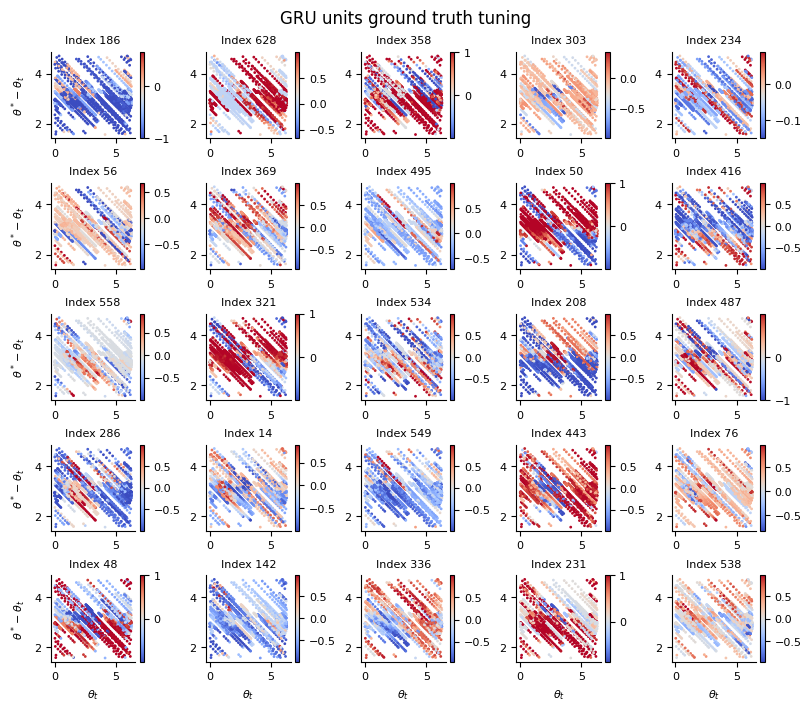

In [8]:
neural_activations_subset = neural_activations_subsampled
num_neurons = neural_activations_subset.shape[-2]
# determine grid size for plotting
cols = 5
# rows = (num_neurons + cols - 1) // cols  # calculate rows dynamically based on number of neurons
rows = 5
# create a grid of heatmaps
fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 7/5), constrained_layout=True)
axes = axes.flatten()
for i, idx in enumerate(subsampling_index_2):
    if i >= len(axes):
        break
    ax = axes[i]
    heatmap = ax.scatter(
        positions_subsampled[:, 0],
        positions_subsampled[:, 1],
        c=neural_activations_subset[0, i, :],
        cmap="coolwarm",
        s = 1,
    )
    ax.set_title(f"Index {subsampling_index_2[i]}")
    if i % cols == 0:
        ax.set_ylabel(r"$\theta^* - \theta_t$")
    if i // cols == rows - 1:
        ax.set_xlabel(r"$\theta_t$")
    fig.colorbar(heatmap, ax=ax, orientation="vertical")

fig.suptitle(f"GRU units ground truth tuning", fontsize=12)
plt.savefig(f"{FIG_PATH}/GT_gru.png", dpi=300, bbox_inches='tight')


Now we have an idea of what stuff actually looks like, we try to fit the supervised mGPLVM to data. 

Note that this plot reveals bias in the sampling procedure. This is expected because we are sampling on control trajectories; expectedly as the controller is trained, the residual motion will be biased toward 0 (or 2pi). 

In [11]:
### set some parameters for fitting ###
max_steps = 1001 # number of training iterations
n_mc = 1 # number of monte carlo samples per iteration (since the latents are a delta function, we only need 1)
print_every = 10 # how often we print training progress
d = 2 # specify the dimensionality of the space
n_z = 50 #number of inducing points; performance increases with more inducing points

In [14]:
def build_model_supervised(): 
    manif = mgp.manifolds.Torus(m, d)
    mu = positions_subsampled.unsqueeze(0)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1, sigma = 1e-5, diagonal = True, mu = mu)
    kernel = mgp.kernels.QuadExp(n, manif.distance, Y = neural_activations_subsampled, ell = np.ones(n)*1, scale = 0.7*np.ones(n)) #squared exponential kernel
    # lik = mgp.likelihoods.Gaussian(n, Y = neural_activations_subsampled, d=d)
    lik = mgp.likelihoods.Gaussian(n, )
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, n_z)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior,
    ).to(device)
    return model

def build_model_unsupervised(): 
    manif = mgp.manifolds.Torus(m, d)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1)
    kernel = mgp.kernels.QuadExp(n, manif.distance)
    lik = mgp.likelihoods.Gaussian(n)
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, 50)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior, whiten = True
    )
    return model


model = build_model_supervised()
unsupervised_model = build_model_unsupervised()

/home/timmy/projects/mental-rotations/src/mgplvm/mgplvm/rdist/relie.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gmu = torch.tensor(mu)


In [15]:
train_params = mgp.crossval.training_params(max_steps = max_steps, n_mc = n_mc, lrate = 5e-2, callback = None, burnin = 50, mask_Ts = (lambda x: x*0))
print('fitting', n, 'neurons and', m, 'conditions for', max_steps, 'iterations')
mod_train = mgp.crossval.train_model(model, neural_activations_subsampled.to(device), train_params)

fitting 100 neurons and 2000 conditions for 1001 iterations
iter   0 | elbo -2.958 | kl  0.239 | loss  2.958 | |mu| 3.721 | sig 0.000 | scale 0.700 | ell 1.000 | lik_sig 1.000 |
iter  50 | elbo -0.900 | kl  0.238 | loss  1.051 | |mu| 3.721 | sig 0.000 | scale 0.667 | ell 1.155 | lik_sig 0.800 |
iter 100 | elbo -0.450 | kl  0.238 | loss  0.656 | |mu| 3.721 | sig 0.000 | scale 0.619 | ell 1.406 | lik_sig 0.397 |
iter 150 | elbo -0.413 | kl  0.239 | loss  0.640 | |mu| 3.721 | sig 0.000 | scale 0.593 | ell 1.405 | lik_sig 0.378 |
iter 200 | elbo -0.403 | kl  0.239 | loss  0.637 | |mu| 3.721 | sig 0.000 | scale 0.579 | ell 1.323 | lik_sig 0.374 |
iter 250 | elbo -0.397 | kl  0.239 | loss  0.634 | |mu| 3.721 | sig 0.000 | scale 0.567 | ell 1.237 | lik_sig 0.371 |
iter 300 | elbo -0.392 | kl  0.239 | loss  0.630 | |mu| 3.721 | sig 0.000 | scale 0.556 | ell 1.159 | lik_sig 0.368 |
iter 350 | elbo -0.387 | kl  0.238 | loss  0.625 | |mu| 3.721 | sig 0.000 | scale 0.543 | ell 1.093 | lik_sig 0.36

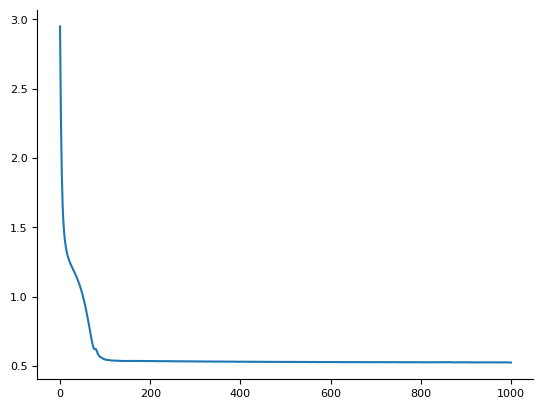

In [131]:
plt.plot(mod_train)

In [22]:
model.load_state_dict(torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2.pt"))

<All keys matched successfully>

Model trained; now visualize the tuning. 

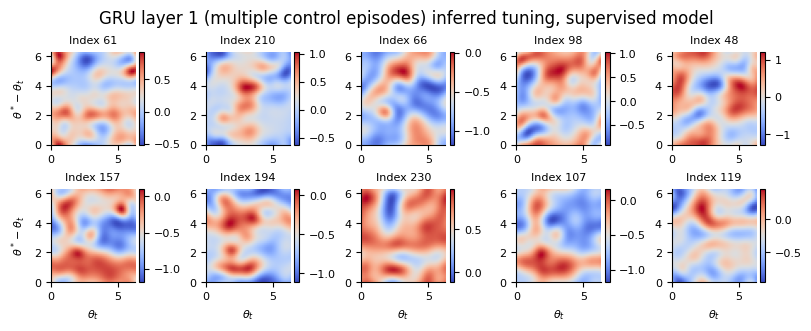

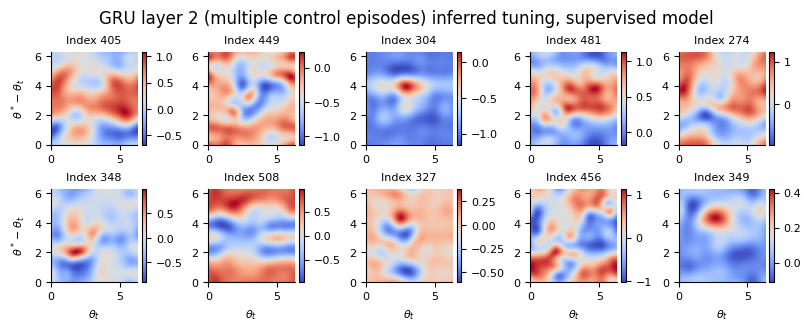

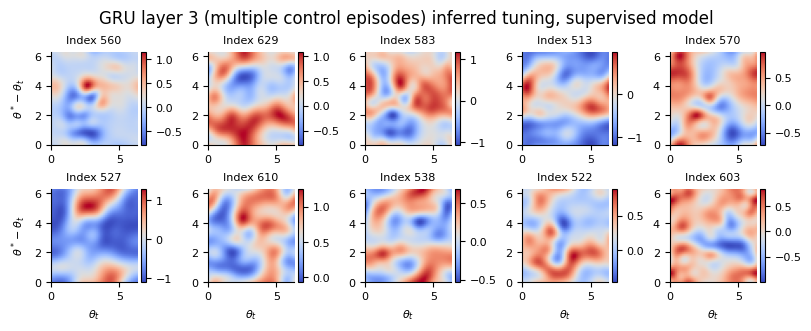

In [17]:
partitions = {
    "1": (0, 255), 
    "2": (256, 511), 
    "3": (512, 640),
}
# Create a meshgrid for the 2D tuning curves
theta1 = np.linspace(0, 2 * np.pi, 50)
theta2 = np.linspace(0, 2 * np.pi, 50)
theta1_mesh, theta2_mesh = np.meshgrid(theta1, theta2)

# Combine the meshgrid into a query tensor
query = torch.tensor(
    np.stack([theta1_mesh.ravel(), theta2_mesh.ravel()], axis=-1),
    dtype=torch.get_default_dtype(),
    device=device,
)[None, ...].unsqueeze(-1)

# Predict mean and variance
model = model.to("cpu")
fmean, fvar = model.obs.predict(query.to("cpu"), full_cov=False)
fstd = fvar.sqrt()

# Reshape the results to match the meshgrid
fmean = fmean[0].cpu().detach().numpy().reshape(50, 50, -1)
fstd = fstd[0].cpu().detach().numpy().reshape(50, 50, -1)

for partition_name, (start, end) in partitions.items():
    # Find the indices in the original dataset
    indices = [i for i in range(fmean.shape[-1]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]

    # Subset the fmean for the current partition
    fmean_subset = fmean[:, :, indices]
    num_neurons = fmean_subset.shape[-1]

    # Determine grid size for plotting
    cols = 5
    # rows = (num_neurons + cols - 1) // cols  # Calculate rows dynamically based on number of neurons
    rows = 2

    # Create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 8/5), constrained_layout=True)
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.imshow(
            fmean_subset[:, :, i],
            extent=(0, 2 * np.pi, 0, 2 * np.pi),
            origin="lower",
            cmap="coolwarm",
            aspect="auto",
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        # fig.colorbar(heatmap, ax=ax, orientation="vertical")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")


    # Add a title for the grid
    plt.suptitle(f"GRU layer {partition_name} (multiple control episodes) inferred tuning, supervised model", fontsize=12)
    plt.savefig(f"{FIG_PATH}/supervised_model_GRU_multi_{partition_name}_{model_name}.png", dpi=300, bbox_inches='tight')
    plt.show()


In [143]:
torch.save(model.state_dict(), "/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2.pt")
torch.save({"index 1": subsampling_index_1, "index 2": subsampling_index_2}, "/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices.pt")

This is much better! and expected too. But what happened? The unsupervised model should have been able to learn this - let's try to reproduce the training conditions and see how exactly the unsupervised model fails.

In [15]:
train_params = mgp.crossval.training_params(max_steps = max_steps, n_mc = n_mc, lrate = 5e-2, callback = None, burnin = 50, mask_Ts = (lambda x: x*0))
print('fitting', n, 'neurons and', m, 'conditions for', max_steps, 'iterations')
mod_train = mgp.crossval.train_model(unsupervised_model.to(device), neural_activations_subsampled.to(device), train_params)

fitting 100 neurons and 1000 conditions for 1001 iterations
iter   0 | elbo -5.368 | kl  0.002 | loss  5.368 | |mu| 0.100 | sig 1.500 | scale 1.000 | ell 2.000 | lik_sig 1.000 |
iter  50 | elbo -1.524 | kl  0.003 | loss  1.526 | |mu| 0.100 | sig 1.500 | scale 0.968 | ell 2.150 | lik_sig 1.069 |
iter 100 | elbo -1.392 | kl  0.002 | loss  1.394 | |mu| 0.100 | sig 1.500 | scale 0.944 | ell 2.251 | lik_sig 0.978 |
iter 150 | elbo -1.356 | kl  0.002 | loss  1.358 | |mu| 0.100 | sig 1.500 | scale 0.914 | ell 2.352 | lik_sig 0.966 |
iter 200 | elbo -1.342 | kl  0.002 | loss  1.344 | |mu| 0.100 | sig 1.500 | scale 0.886 | ell 2.455 | lik_sig 0.975 |
iter 250 | elbo -1.335 | kl  0.002 | loss  1.337 | |mu| 0.100 | sig 1.500 | scale 0.859 | ell 2.566 | lik_sig 0.979 |
iter 300 | elbo -1.331 | kl  0.002 | loss  1.334 | |mu| 0.100 | sig 1.500 | scale 0.833 | ell 2.687 | lik_sig 0.981 |
iter 350 | elbo -1.328 | kl  0.002 | loss  1.330 | |mu| 0.100 | sig 1.500 | scale 0.808 | ell 2.811 | lik_sig 0.98

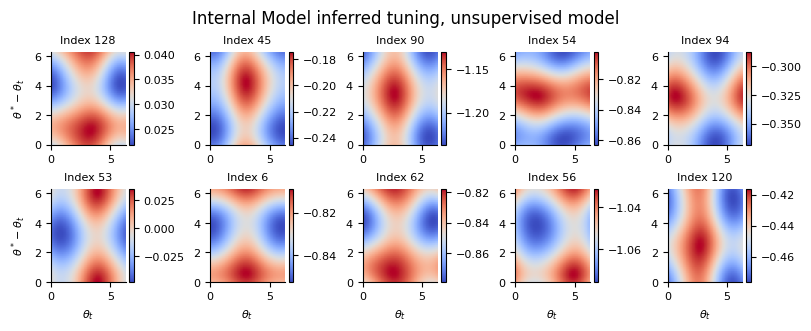

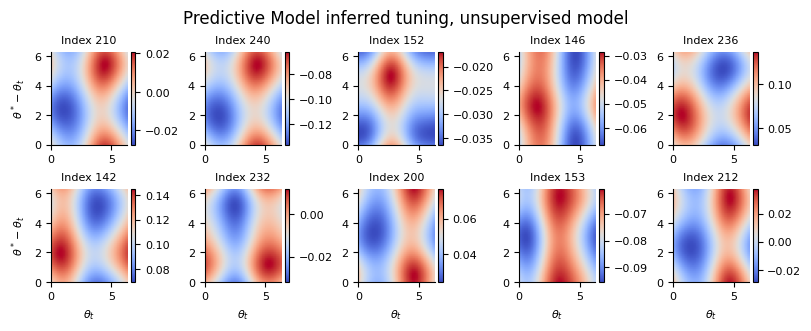

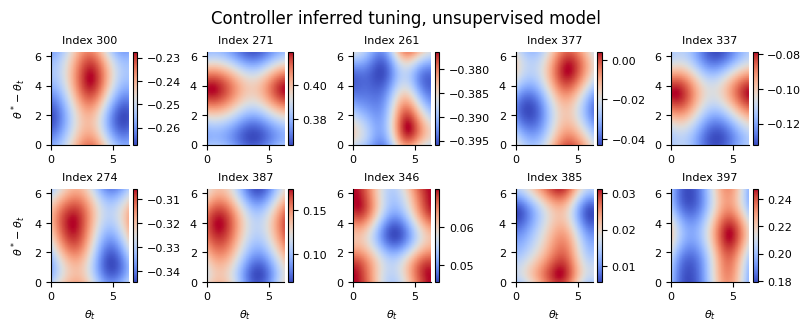

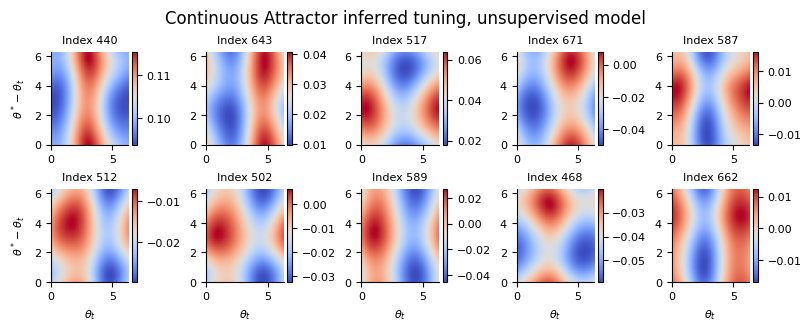

In [20]:
# Create a meshgrid for the 2D tuning curves
theta1 = np.linspace(0, 2 * np.pi, 50)
theta2 = np.linspace(0, 2 * np.pi, 50)
theta1_mesh, theta2_mesh = np.meshgrid(theta1, theta2)

# Combine the meshgrid into a query tensor
query = torch.tensor(
    np.stack([theta1_mesh.ravel(), theta2_mesh.ravel()], axis=-1),
    dtype=torch.get_default_dtype(),
    device=device,
)[None, ...].unsqueeze(-1)

# Predict mean and variance
unsupervised_model = unsupervised_model.to("cpu")
fmean, fvar = unsupervised_model.obs.predict(query.to("cpu"), full_cov=False)
fstd = fvar.sqrt()

# Reshape the results to match the meshgrid
fmean = fmean[0].cpu().detach().numpy().reshape(50, 50, -1)
fstd = fstd[0].cpu().detach().numpy().reshape(50, 50, -1)

# Iterate over each partition and plot separately
for partition_name, (start, end) in partitions.items():
    # Find the indices in the original dataset
    indices = [i for i in range(fmean.shape[-1]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]
    
    # Subset the fmean for the current partition
    fmean_subset = fmean[:, :, indices]
    num_neurons = fmean_subset.shape[-1]
    
    # Determine grid size for plotting
    cols = 5
    # rows = (num_neurons + cols - 1) // cols  # Calculate rows dynamically based on number of neurons
    rows = 2
    
    # Create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 8/5), constrained_layout=True)
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.imshow(
            fmean_subset[:, :, i],
            extent=(0, 2 * np.pi, 0, 2 * np.pi),
            origin="lower",
            cmap="coolwarm",
            aspect="auto",
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        # fig.colorbar(heatmap, ax=ax, orientation="vertical")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")
    
   
    # Add a title for the grid
    plt.suptitle(f"{partition_name} inferred tuning, unsupervised model", fontsize=12)
    plt.savefig(f"{FIG_PATH}/unsupervised_model_modular_{partition_name}.png", dpi=300, bbox_inches='tight')



In [21]:
torch.save(unsupervised_model.state_dict(), "/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_unsupervised_t2.pt")